# GroupNorm vs InstanceNorm Experiment

## Hypothesis
- **GroupNorm (GN)**: May encourage smoother, more connected masks → helps Dice but could create bridges
- **InstanceNorm (IN)**: May produce sharper boundaries → could reduce bridges but increase fragmentation

## Metrics to Compare
1. **Dice Score** - Overall segmentation quality
2. **Number of Connected Components** - Fragmentation indicator
3. **Bridge Detection** - Merge/split errors
4. **Component Size Distribution** - Are we getting many small fragments or few large ones?

## Experiment Design
- Same seed, same LR schedule, same loss
- Only change: GN → IN in the model
- Train for ~50 epochs (enough to see trends)
- Compare validation masks

In [1]:
# =============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# =============================================================================
# OPTIMIZED FOR: 16GB GPU + 29GB RAM

import os
import gc
import json
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass
import time

import numpy as np
import pandas as pd
from PIL import Image, ImageSequence
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from scipy import ndimage
from scipy.ndimage import distance_transform_edt, label as scipy_label

# Use scipy's skeletonize instead of skimage (avoids dependency issues)
try:
    from skimage.morphology import skeletonize_3d
    HAS_SKIMAGE_SKEL = True
except ImportError:
    HAS_SKIMAGE_SKEL = False
    print("skimage.morphology.skeletonize_3d not available, using simplified skeleton")

try:
    import cc3d
    USE_CC3D = True
except ImportError:
    USE_CC3D = False
    print("cc3d not found, using scipy for connected components")

warnings.filterwarnings('ignore')

# =============================================================================
# EXPERIMENT CONFIGURATION - OPTIMIZED FOR 16GB GPU + 29GB RAM
# =============================================================================

@dataclass
class ExperimentConfig:
    # Data paths
    DATA_ROOT: Path = Path("/kaggle/input/vesuvius-challenge-surface-detection")
    OUTPUT_DIR: Path = Path("/kaggle/working/gn_vs_in_experiment")

    # Model architecture - REDUCED FOR 16GB GPU
    PATCH_SIZE: Tuple[int, int, int] = (96, 96, 96)  # Smaller patches for 16GB GPU
    FEATURES: List[int] = None
    N_BLOCKS: List[int] = None
    USE_SCSE: bool = True
    USE_DEEP_SUPERVISION: bool = False  # Disabled to save memory

    # Training settings - SHORT EXPERIMENT
    EPOCHS: int = 30  # Shorter experiment
    BATCH_SIZE: int = 1  # Batch size 1 for 16GB GPU
    NUM_WORKERS: int = 0  # NO multiprocessing to avoid Kaggle issues
    LEARNING_RATE: float = 0.01
    MOMENTUM: float = 0.99
    WEIGHT_DECAY: float = 3e-5
    GRADIENT_CLIP: float = 12.0

    # Loss weights (same for both experiments)
    DICE_WEIGHT: float = 0.5
    BCE_WEIGHT: float = 0.5

    # Validation
    VALIDATE_EVERY: int = 5

    # Device
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    USE_AMP: bool = True  # Essential for 16GB GPU

    # Data loading - REDUCED FOR 29GB RAM
    DATA_FRACTION: float = 0.2  # Use 20% of data to fit in RAM
    PATCHES_PER_VOLUME: int = 2  # Fewer patches per volume

    # Random seed - SAME FOR BOTH
    SEED: int = 42

    def __post_init__(self):
        if self.FEATURES is None:
            self.FEATURES = [24, 48, 96, 192, 256]  # Smaller model for 16GB GPU
        if self.N_BLOCKS is None:
            self.N_BLOCKS = [1, 2, 2, 3, 3]  # Fewer blocks
        self.OUTPUT_DIR = Path(self.OUTPUT_DIR)
        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cfg = ExperimentConfig()
cfg.__post_init__()

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

print("="*60)
print("GN vs IN EXPERIMENT")
print("="*60)
print(f"Hardware: 16GB GPU + 29GB RAM")
print(f"Patch size: {cfg.PATCH_SIZE}")
print(f"Batch size: {cfg.BATCH_SIZE}")
print(f"Model features: {cfg.FEATURES}")
print(f"Epochs: {cfg.EPOCHS}")
print(f"Data fraction: {cfg.DATA_FRACTION}")
print(f"Seed: {cfg.SEED}")
print(f"Num workers: {cfg.NUM_WORKERS} (no multiprocessing)")
print("="*60)
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

skimage.morphology.skeletonize_3d not available, using simplified skeleton
cc3d not found, using scipy for connected components
GN vs IN EXPERIMENT
Hardware: 16GB GPU + 29GB RAM
Patch size: (96, 96, 96)
Batch size: 1
Model features: [24, 48, 96, 192, 256]
Epochs: 30
Data fraction: 0.2
Seed: 42
Num workers: 0 (no multiprocessing)
GPU: Tesla P100-PCIE-16GB
GPU Memory: 17.1 GB


In [2]:
# =============================================================================
# CELL 2: DATASET (On-the-fly loading to save RAM)
# =============================================================================

def load_volume_fast(path: Path) -> np.ndarray:
    """Load 3D TIF volume."""
    try:
        import tifffile
        return tifffile.imread(str(path))
    except ImportError:
        im = Image.open(path)
        slices = [np.array(page) for page in ImageSequence.Iterator(im)]
        return np.stack(slices, axis=0)


class SimpleDataset(Dataset):
    """
    Memory-efficient dataset - loads volumes on-the-fly.
    Optimized for 29GB RAM.
    """
    
    def __init__(
        self,
        csv_path: Path,
        images_dir: Path,
        labels_dir: Path,
        patch_size: Tuple[int, int, int],
        is_train: bool = True,
        data_fraction: float = 1.0,
        patches_per_volume: int = 2,
    ):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.patch_size = patch_size
        self.is_train = is_train
        self.patches_per_volume = patches_per_volume
        
        # Load CSV and filter
        df = pd.read_csv(csv_path)
        valid_ids = []
        for idx in df['id'].values:
            if (self.images_dir / f"{idx}.tif").exists() and \
               (self.labels_dir / f"{idx}.tif").exists():
                valid_ids.append(idx)
        
        if data_fraction < 1.0:
            n = max(1, int(len(valid_ids) * data_fraction))
            random.shuffle(valid_ids)
            valid_ids = valid_ids[:n]
        
        self.volume_ids = valid_ids
        
        # Cache for recently loaded volumes (LRU-style, keep only 2)
        self._cache = {}
        self._cache_order = []
        self._max_cache = 2
        
        print(f"Dataset: {len(self.volume_ids)} volumes, {len(self)} samples")
        print(f"Loading volumes on-the-fly (memory efficient)")
    
    def _get_volume(self, vol_id):
        """Get volume from cache or load from disk."""
        if vol_id in self._cache:
            return self._cache[vol_id]
        
        # Load volume
        img = load_volume_fast(self.images_dir / f"{vol_id}.tif").astype(np.float32)
        lbl = load_volume_fast(self.labels_dir / f"{vol_id}.tif").astype(np.uint8)
        
        # Normalize
        img = (img - img.mean()) / (img.std() + 1e-8)
        
        # Update cache
        self._cache[vol_id] = (img, lbl)
        self._cache_order.append(vol_id)
        
        # Remove oldest if cache is full
        while len(self._cache) > self._max_cache:
            oldest = self._cache_order.pop(0)
            if oldest in self._cache:
                del self._cache[oldest]
        
        return img, lbl
    
    def __len__(self):
        return len(self.volume_ids) * self.patches_per_volume
    
    def __getitem__(self, idx):
        vol_idx = idx // self.patches_per_volume
        vol_id = self.volume_ids[vol_idx]
        
        image, label = self._get_volume(vol_id)
        d, h, w = image.shape
        pd, ph, pw = self.patch_size
        
        # Pad if needed
        if d < pd or h < ph or w < pw:
            pad_d, pad_h, pad_w = max(0, pd-d), max(0, ph-h), max(0, pw-w)
            image = np.pad(image, ((0,pad_d),(0,pad_h),(0,pad_w)), mode='reflect')
            label = np.pad(label, ((0,pad_d),(0,pad_h),(0,pad_w)), mode='constant', constant_values=2)
            d, h, w = image.shape
        
        # Random crop
        z = random.randint(0, max(0, d - pd))
        y = random.randint(0, max(0, h - ph))
        x = random.randint(0, max(0, w - pw))
        
        img_patch = image[z:z+pd, y:y+ph, x:x+pw].copy()
        lbl_patch = label[z:z+pd, y:y+ph, x:x+pw].copy()
        
        # Simple augmentation
        if self.is_train:
            for ax in range(3):
                if random.random() > 0.5:
                    img_patch = np.flip(img_patch, ax)
                    lbl_patch = np.flip(lbl_patch, ax)
            img_patch = np.ascontiguousarray(img_patch)
            lbl_patch = np.ascontiguousarray(lbl_patch)
        
        fg_mask = (lbl_patch == 1).astype(np.float32)
        ig_mask = (lbl_patch == 2).astype(np.float32)
        
        return {
            'image': torch.from_numpy(img_patch).unsqueeze(0).float(),
            'label': torch.from_numpy(fg_mask).unsqueeze(0).float(),
            'ignore_mask': torch.from_numpy(ig_mask).unsqueeze(0).float(),
        }

print("Dataset class defined (memory-efficient, on-the-fly loading)")

Dataset class defined (memory-efficient, on-the-fly loading)


In [3]:
# =============================================================================
# CELL 3: MODELS - GroupNorm vs InstanceNorm
# =============================================================================

class ConvBlockGN(nn.Module):
    """3D convolution block with GroupNorm."""
    def __init__(self, in_ch, out_ch, num_groups=8):
        super().__init__()
        num_groups = min(num_groups, out_ch)
        while out_ch % num_groups != 0:
            num_groups -= 1
        
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(num_groups, out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)


class ConvBlockIN(nn.Module):
    """3D convolution block with InstanceNorm."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)


class ResBlockGN(nn.Module):
    """Residual block with GroupNorm."""
    def __init__(self, channels, n_convs=2):
        super().__init__()
        self.blocks = nn.Sequential(
            *[ConvBlockGN(channels, channels) for _ in range(n_convs)]
        )
    
    def forward(self, x):
        return x + self.blocks(x)


class ResBlockIN(nn.Module):
    """Residual block with InstanceNorm."""
    def __init__(self, channels, n_convs=2):
        super().__init__()
        self.blocks = nn.Sequential(
            *[ConvBlockIN(channels, channels) for _ in range(n_convs)]
        )
    
    def forward(self, x):
        return x + self.blocks(x)


class scSEBlock(nn.Module):
    """Concurrent Spatial and Channel Squeeze-and-Excitation."""
    def __init__(self, channels, reduction=2):
        super().__init__()
        self.cse_pool = nn.AdaptiveAvgPool3d(1)
        self.cse_fc1 = nn.Linear(channels, channels // reduction)
        self.cse_fc2 = nn.Linear(channels // reduction, channels)
        self.sse_conv = nn.Conv3d(channels, 1, 1)
    
    def forward(self, x):
        b, c, d, h, w = x.shape
        cse = self.cse_pool(x).view(b, c)
        cse = F.relu(self.cse_fc1(cse))
        cse = torch.sigmoid(self.cse_fc2(cse)).view(b, c, 1, 1, 1)
        sse = torch.sigmoid(self.sse_conv(x))
        return x * cse + x * sse


def create_unet(norm_type: str, features: List[int], n_blocks: List[int], use_scse: bool = True):
    """
    Create U-Net with specified normalization type.
    
    Args:
        norm_type: 'GN' for GroupNorm, 'IN' for InstanceNorm
        features: Feature channels per stage
        n_blocks: Number of residual blocks per stage
        use_scse: Whether to use scSE attention
    """
    
    class UNet3D(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.norm_type = norm_type
            ConvBlock = ConvBlockGN if norm_type == 'GN' else ConvBlockIN
            ResBlock = ResBlockGN if norm_type == 'GN' else ResBlockIN
            
            # Encoder
            self.encoders = nn.ModuleList()
            self.attentions = nn.ModuleList()
            self.pools = nn.ModuleList()
            
            for i, (feat, nb) in enumerate(zip(features, n_blocks)):
                in_channels = 1 if i == 0 else features[i - 1]
                encoder = nn.Sequential(
                    ConvBlock(in_channels, feat),
                    *[ResBlock(feat, n_convs=2) for _ in range(nb)]
                )
                self.encoders.append(encoder)
                
                if use_scse:
                    self.attentions.append(scSEBlock(feat))
                else:
                    self.attentions.append(nn.Identity())
                
                if i < len(features) - 1:
                    self.pools.append(nn.Conv3d(feat, feat, kernel_size=2, stride=2))
            
            # Decoder
            self.ups = nn.ModuleList()
            self.dec_convs = nn.ModuleList()
            
            for i in range(len(features) - 2, -1, -1):
                up_feat = features[i + 1]
                out_feat = features[i]
                self.ups.append(nn.ConvTranspose3d(up_feat, out_feat, kernel_size=2, stride=2))
                self.dec_convs.append(ConvBlock(out_feat * 2, out_feat))
            
            self.final = nn.Conv3d(features[0], 1, 1)
        
        def forward(self, x):
            enc_features = []
            
            for i, (enc, att) in enumerate(zip(self.encoders, self.attentions)):
                x = enc(x)
                x = att(x)
                enc_features.append(x)
                if i < len(self.pools):
                    x = self.pools[i](x)
            
            enc_features = enc_features[::-1]
            x = enc_features[0]
            
            for i, (up, dec) in enumerate(zip(self.ups, self.dec_convs)):
                x = up(x)
                skip = enc_features[i + 1]
                
                if x.shape[2:] != skip.shape[2:]:
                    x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
                
                x = torch.cat([x, skip], dim=1)
                x = dec(x)
            
            return self.final(x)
    
    return UNet3D()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Test model creation
print("Testing model creation...")
model_gn = create_unet('GN', cfg.FEATURES, cfg.N_BLOCKS)
model_in = create_unet('IN', cfg.FEATURES, cfg.N_BLOCKS)
print(f"GroupNorm model params: {count_parameters(model_gn):,}")
print(f"InstanceNorm model params: {count_parameters(model_in):,}")
del model_gn, model_in
gc.collect()

Testing model creation...
GroupNorm model params: 23,592,634
InstanceNorm model params: 23,592,634


24

In [4]:
# =============================================================================
# CELL 4: LOSS FUNCTIONS (Same for both experiments)
# =============================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-5):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target, mask=None):
        pred = torch.sigmoid(pred)
        
        if mask is not None:
            pred = pred * (1 - mask)
            target = target * (1 - mask)
        
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice


class BCEWithMask(nn.Module):
    def forward(self, pred, target, mask=None):
        if mask is not None:
            valid = 1 - mask
            loss = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
            loss = (loss * valid).sum() / (valid.sum() + 1e-8)
        else:
            loss = F.binary_cross_entropy_with_logits(pred, target)
        return loss


class SimpleLoss(nn.Module):
    """Simple Dice + BCE loss (same for both experiments)."""
    def __init__(self, dice_weight: float = 0.5, bce_weight: float = 0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.dice_loss = DiceLoss()
        self.bce_loss = BCEWithMask()
    
    def forward(self, pred, target, ignore_mask):
        dice = self.dice_loss(pred, target, ignore_mask)
        bce = self.bce_loss(pred, target, ignore_mask)
        total = self.dice_weight * dice + self.bce_weight * bce
        return {'total': total, 'dice': dice.item(), 'bce': bce.item()}

print("Loss functions defined")

Loss functions defined


In [5]:
# =============================================================================
# CELL 5: TOPOLOGY ANALYSIS FUNCTIONS
# =============================================================================

def connected_components_3d(volume, connectivity=26):
    """Compute 3D connected components."""
    if USE_CC3D:
        return cc3d.connected_components(volume.astype(np.uint8), connectivity=connectivity)
    else:
        if connectivity == 26:
            struct = ndimage.generate_binary_structure(3, 3)
        elif connectivity == 6:
            struct = ndimage.generate_binary_structure(3, 1)
        else:
            struct = ndimage.generate_binary_structure(3, 2)
        labeled, _ = ndimage.label(volume, structure=struct)
        return labeled


def simple_skeletonize_3d(binary_volume):
    """
    Simple skeleton approximation using erosion.
    Not a true skeleton but captures the medial structure.
    Works without skimage dependency.
    """
    # Iteratively erode until we get thin structures
    skel = np.zeros_like(binary_volume, dtype=bool)
    current = binary_volume.astype(bool).copy()
    
    struct = ndimage.generate_binary_structure(3, 1)  # 6-connectivity
    
    iteration = 0
    max_iterations = 50
    
    while current.sum() > 0 and iteration < max_iterations:
        # Erode
        eroded = ndimage.binary_erosion(current, struct)
        
        # Points that would be removed but are endpoints (have few neighbors)
        # are skeleton candidates
        boundary = current & ~eroded
        
        # Add to skeleton if this is a thin structure
        if eroded.sum() == 0:
            # Last layer - add all remaining
            skel |= current
            break
        
        current = eroded
        iteration += 1
    
    # The remaining points after erosion are the skeleton core
    skel |= current
    
    return skel


def skeletonize_volume(binary_volume):
    """Skeletonize using best available method."""
    if HAS_SKIMAGE_SKEL:
        return skeletonize_3d(binary_volume.astype(bool))
    else:
        return simple_skeletonize_3d(binary_volume)


def analyze_topology(pred_binary: np.ndarray, gt_binary: np.ndarray) -> dict:
    """
    Analyze topology of prediction vs ground truth.
    
    Returns:
        dict with metrics:
        - n_components_pred: Number of connected components in prediction
        - n_components_gt: Number of connected components in ground truth
        - component_ratio: pred_components / gt_components (>1 = fragmentation, <1 = merging)
        - avg_component_size_pred: Average size of prediction components
        - avg_component_size_gt: Average size of GT components
        - size_ratio: pred_avg_size / gt_avg_size
        - dice: Dice score
        - bridge_score: Estimate of bridges (oversimplified)
    """
    # Connected components
    pred_labels = connected_components_3d(pred_binary)
    gt_labels = connected_components_3d(gt_binary)
    
    n_pred = pred_labels.max()
    n_gt = gt_labels.max()
    
    # Component sizes
    pred_sizes = []
    for i in range(1, n_pred + 1):
        pred_sizes.append((pred_labels == i).sum())
    
    gt_sizes = []
    for i in range(1, n_gt + 1):
        gt_sizes.append((gt_labels == i).sum())
    
    avg_pred_size = np.mean(pred_sizes) if pred_sizes else 0
    avg_gt_size = np.mean(gt_sizes) if gt_sizes else 1
    
    # Dice
    intersection = (pred_binary & gt_binary).sum()
    union = pred_binary.sum() + gt_binary.sum()
    dice = (2 * intersection + 1e-5) / (union + 1e-5)
    
    # Bridge detection (simplified): 
    # If pred has fewer components but similar FG%, it's likely bridging
    fg_pred = pred_binary.sum() / pred_binary.size
    fg_gt = gt_binary.sum() / gt_binary.size
    
    # Bridge score: higher = more likely bridges
    # If we have fewer components than GT but similar coverage, we're merging
    if n_gt > 0 and n_pred > 0:
        component_ratio = n_pred / n_gt
        # Bridge score: low component ratio + high coverage = bridges
        if component_ratio < 0.5 and fg_pred > fg_gt * 0.8:
            bridge_score = (1 - component_ratio) * (fg_pred / (fg_gt + 1e-8))
        else:
            bridge_score = 0
    else:
        component_ratio = 1
        bridge_score = 0
    
    # Fragmentation score: many small components
    small_component_count = sum(1 for s in pred_sizes if s < avg_gt_size * 0.1)
    fragmentation_score = small_component_count / max(n_pred, 1)
    
    return {
        'n_components_pred': n_pred,
        'n_components_gt': n_gt,
        'component_ratio': component_ratio,
        'avg_component_size_pred': avg_pred_size,
        'avg_component_size_gt': avg_gt_size,
        'size_ratio': avg_pred_size / (avg_gt_size + 1e-8),
        'dice': dice,
        'fg_pred': fg_pred,
        'fg_gt': fg_gt,
        'bridge_score': bridge_score,
        'fragmentation_score': fragmentation_score,
        'small_components': small_component_count,
    }


def compute_skeleton_metrics(pred_binary: np.ndarray, gt_binary: np.ndarray) -> dict:
    """
    Compute skeleton-based metrics.
    
    - Skeleton recall: How much of GT skeleton is captured by prediction
    - Skeleton precision: How much of pred skeleton overlaps with GT
    """
    # Skeletonize using available method
    pred_skel = skeletonize_volume(pred_binary)
    gt_skel = skeletonize_volume(gt_binary)
    
    # Dilate GT skeleton slightly for tolerance
    gt_skel_dilated = ndimage.binary_dilation(gt_skel, iterations=2)
    pred_skel_dilated = ndimage.binary_dilation(pred_skel, iterations=2)
    
    # Skeleton recall: pred captures GT skeleton
    if gt_skel.sum() > 0:
        skel_recall = (pred_binary & gt_skel_dilated).sum() / gt_skel.sum()
    else:
        skel_recall = 1.0
    
    # Skeleton precision: pred skeleton is on GT
    if pred_skel.sum() > 0:
        skel_precision = (pred_skel & gt_binary).sum() / pred_skel.sum()
    else:
        skel_precision = 0.0
    
    return {
        'skel_recall': min(skel_recall, 1.0),  # Cap at 1.0
        'skel_precision': skel_precision,
        'skel_f1': 2 * min(skel_recall, 1.0) * skel_precision / (min(skel_recall, 1.0) + skel_precision + 1e-8),
        'pred_skel_voxels': pred_skel.sum(),
        'gt_skel_voxels': gt_skel.sum(),
    }

print("Topology analysis functions defined")
print(f"Skeleton method: {'skimage.skeletonize_3d' if HAS_SKIMAGE_SKEL else 'simple erosion-based'}")

Topology analysis functions defined
Skeleton method: simple erosion-based


In [6]:
# =============================================================================
# CELL 6: TRAINING FUNCTIONS
# =============================================================================

import sys

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    total_dice = 0
    n_batches = 0
    
    for batch in tqdm(loader, desc="Train", file=sys.stdout, leave=False):
        images = batch['image'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        ignore = batch['ignore_mask'].to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast(enabled=cfg.USE_AMP):
            output = model(images)
            losses = criterion(output, labels, ignore)
        
        scaler.scale(losses['total']).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRADIENT_CLIP)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += losses['total'].item()
        total_dice += losses['dice']
        n_batches += 1
    
    return {
        'train_loss': total_loss / n_batches,
        'train_dice': total_dice / n_batches,
    }


@torch.no_grad()
def validate_with_topology(model, loader, device, threshold=0.5):
    """
    Validation with topology analysis.
    Returns Dice + topology metrics.
    """
    model.eval()
    
    all_metrics = []
    
    for batch in tqdm(loader, desc="Val", file=sys.stdout, leave=False):
        images = batch['image'].to(device, non_blocking=True)
        labels = batch['label'].numpy()
        ignore = batch['ignore_mask'].numpy()
        
        with autocast(enabled=cfg.USE_AMP):
            output = model(images)
            probs = torch.sigmoid(output).cpu().numpy()
        
        for b in range(images.shape[0]):
            pred_binary = (probs[b, 0] > threshold).astype(np.uint8)
            gt_binary = (labels[b, 0] > 0.5).astype(np.uint8)
            ign = ignore[b, 0] > 0.5
            
            # Mask out ignore regions
            pred_binary[ign] = 0
            gt_binary[ign] = 0
            
            # Topology analysis
            topo_metrics = analyze_topology(pred_binary, gt_binary)
            
            # Skeleton metrics (slower, do for subset)
            if len(all_metrics) < 10:  # Only compute for first 10
                skel_metrics = compute_skeleton_metrics(pred_binary, gt_binary)
                topo_metrics.update(skel_metrics)
            
            all_metrics.append(topo_metrics)
    
    # Average metrics
    avg_metrics = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics if key in m]
        avg_metrics[key] = np.mean(values)
    
    return avg_metrics

print("Training functions defined")

Training functions defined


In [7]:
# =============================================================================
# CELL 7: RUN EXPERIMENT (Memory-optimized for 16GB GPU)
# =============================================================================

def run_experiment(norm_type: str):
    """
    Run training experiment with specified normalization.
    Memory-optimized for 16GB GPU + 29GB RAM.
    
    Args:
        norm_type: 'GN' or 'IN'
    
    Returns:
        dict with training history and final metrics
    """
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {norm_type}")
    print(f"{'='*60}")
    
    # Aggressive cleanup before starting
    gc.collect()
    torch.cuda.empty_cache()
    
    # Set seed for reproducibility
    set_seed(cfg.SEED)
    
    # Create datasets
    train_csv = cfg.DATA_ROOT / "train.csv"
    train_images = cfg.DATA_ROOT / "train_images"
    train_labels = cfg.DATA_ROOT / "train_labels"
    
    train_dataset = SimpleDataset(
        csv_path=train_csv,
        images_dir=train_images,
        labels_dir=train_labels,
        patch_size=cfg.PATCH_SIZE,
        is_train=True,
        data_fraction=cfg.DATA_FRACTION,
        patches_per_volume=cfg.PATCHES_PER_VOLUME,
    )
    
    val_dataset = SimpleDataset(
        csv_path=train_csv,
        images_dir=train_images,
        labels_dir=train_labels,
        patch_size=cfg.PATCH_SIZE,
        is_train=False,
        data_fraction=0.1,  # Even smaller for validation
        patches_per_volume=1,
    )
    
    # NO multiprocessing (num_workers=0) to avoid Kaggle issues
    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=0,  # No multiprocessing
        pin_memory=True,
        drop_last=True,
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=0,  # No multiprocessing
        pin_memory=True,
    )
    
    # Create model
    model = create_unet(norm_type, cfg.FEATURES, cfg.N_BLOCKS, use_scse=cfg.USE_SCSE)
    model = model.to(cfg.DEVICE)
    print(f"Model created: {count_parameters(model):,} parameters")
    
    # Print GPU memory after model creation
    if torch.cuda.is_available():
        print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    
    # Loss, optimizer, scheduler
    criterion = SimpleLoss(dice_weight=cfg.DICE_WEIGHT, bce_weight=cfg.BCE_WEIGHT)
    
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=cfg.LEARNING_RATE * cfg.BATCH_SIZE,
        momentum=cfg.MOMENTUM,
        weight_decay=cfg.WEIGHT_DECAY,
        nesterov=True,
    )
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda e: (1 - e / cfg.EPOCHS) ** 0.9
    )
    
    scaler = GradScaler(enabled=cfg.USE_AMP)
    
    # Training loop
    history = {
        'norm_type': norm_type,
        'epochs': [],
        'train_loss': [],
        'train_dice': [],
        'val_dice': [],
        'val_n_components': [],
        'val_component_ratio': [],
        'val_bridge_score': [],
        'val_fragmentation': [],
        'val_skel_recall': [],
        'val_skel_precision': [],
    }
    
    for epoch in range(cfg.EPOCHS):
        epoch_start = time.time()
        
        # Train
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scaler, cfg.DEVICE)
        scheduler.step()
        
        # Clear cache periodically
        if epoch % 5 == 0:
            torch.cuda.empty_cache()
        
        # Validate with topology analysis
        if (epoch + 1) % cfg.VALIDATE_EVERY == 0:
            val_metrics = validate_with_topology(model, val_loader, cfg.DEVICE)
            
            history['epochs'].append(epoch + 1)
            history['train_loss'].append(train_metrics['train_loss'])
            history['train_dice'].append(train_metrics['train_dice'])
            history['val_dice'].append(val_metrics['dice'])
            history['val_n_components'].append(val_metrics['n_components_pred'])
            history['val_component_ratio'].append(val_metrics['component_ratio'])
            history['val_bridge_score'].append(val_metrics['bridge_score'])
            history['val_fragmentation'].append(val_metrics['fragmentation_score'])
            history['val_skel_recall'].append(val_metrics.get('skel_recall', 0))
            history['val_skel_precision'].append(val_metrics.get('skel_precision', 0))
            
            epoch_time = time.time() - epoch_start
            print(f"Epoch {epoch+1}/{cfg.EPOCHS} | {epoch_time:.1f}s | "
                  f"Loss: {train_metrics['train_loss']:.4f} | "
                  f"Val Dice: {val_metrics['dice']:.4f} | "
                  f"Components: {val_metrics['n_components_pred']:.0f} (ratio: {val_metrics['component_ratio']:.2f}) | "
                  f"Bridge: {val_metrics['bridge_score']:.3f} | "
                  f"Frag: {val_metrics['fragmentation_score']:.3f}")
            
            # Clear GPU cache after validation
            torch.cuda.empty_cache()
        else:
            epoch_time = time.time() - epoch_start
            print(f"Epoch {epoch+1}/{cfg.EPOCHS} | {epoch_time:.1f}s | "
                  f"Loss: {train_metrics['train_loss']:.4f} | "
                  f"Train Dice: {1 - train_metrics['train_dice']:.4f}")
    
    # Final detailed validation
    print(f"\nFinal validation for {norm_type}...")
    final_metrics = validate_with_topology(model, val_loader, cfg.DEVICE)
    history['final_metrics'] = final_metrics
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'norm_type': norm_type,
        'history': history,
    }, cfg.OUTPUT_DIR / f'model_{norm_type}.pth')
    
    # Aggressive cleanup
    del model, optimizer, scheduler, scaler, criterion
    del train_dataset, val_dataset, train_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()
    
    print(f"\n{norm_type} experiment complete. GPU memory freed.")
    if torch.cuda.is_available():
        print(f"GPU memory allocated after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    
    return history

print("Experiment function defined (no multiprocessing, memory-optimized)")

Experiment function defined (no multiprocessing, memory-optimized)


In [8]:
# =============================================================================
# CELL 8: RUN BOTH EXPERIMENTS
# =============================================================================

# Run GroupNorm experiment
print("\n" + "#"*60)
print("# EXPERIMENT 1: GroupNorm")
print("#"*60)
history_gn = run_experiment('GN')

# Run InstanceNorm experiment
print("\n" + "#"*60)
print("# EXPERIMENT 2: InstanceNorm")
print("#"*60)
history_in = run_experiment('IN')

# Save combined results
results = {
    'GroupNorm': history_gn,
    'InstanceNorm': history_in,
}
with open(cfg.OUTPUT_DIR / 'experiment_results.json', 'w') as f:
    json.dump(results, f, indent=2, default=float)

print("\n" + "="*60)
print("EXPERIMENTS COMPLETE")
print("="*60)


############################################################
# EXPERIMENT 1: GroupNorm
############################################################

EXPERIMENT: GN
Dataset: 157 volumes, 314 samples
Loading volumes on-the-fly (memory efficient)
Dataset: 78 volumes, 78 samples
Loading volumes on-the-fly (memory efficient)
Model created: 23,592,634 parameters
GPU memory allocated: 0.10 GB


Train:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 1/30 | 319.5s | Loss: 0.5191 | Train Dice: 0.2985


Train:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 2/30 | 319.9s | Loss: 0.5078 | Train Dice: 0.3086


...

Train:   0%|          | 0/314 [00:00<?, ?it/s]

Val:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 30/30 | 360.9s | Loss: 0.4952 | Val Dice: 0.2329 | Components: 51 (ratio: 14.10) | Bridge: 0.000 | Frag: 0.847

Final validation for IN...


Val:   0%|          | 0/78 [00:00<?, ?it/s]


IN experiment complete. GPU memory freed.
GPU memory allocated after cleanup: 0.02 GB

EXPERIMENTS COMPLETE


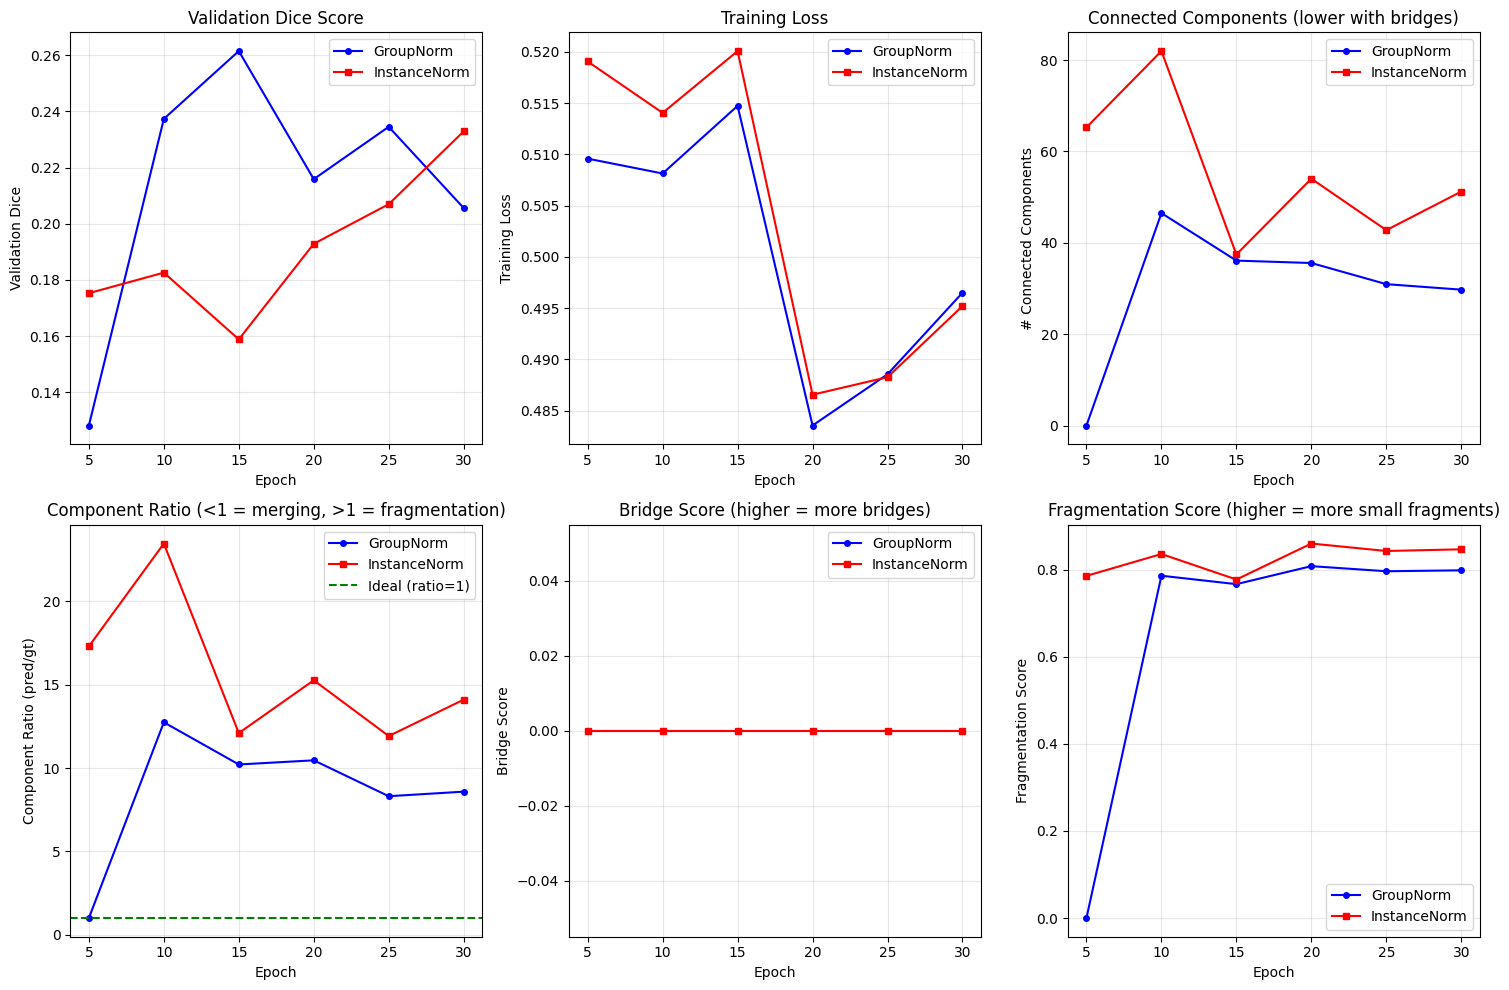


SUMMARY: GroupNorm vs InstanceNorm

--- Final Validation Metrics ---
Metric                       GroupNorm InstanceNorm       Winner
-------------------------------------------------------------
Dice Score                      0.2682       0.3029           IN
# Components (pred)            25.6154      44.6667            -
# Components (gt)               3.3205       3.3205            -
Component Ratio                 7.5425      12.2712           GN
Bridge Score                    0.0000       0.0000           IN
Fragmentation Score             0.7656       0.8098           GN
Skeleton Recall                 0.3974       0.5929           IN
Skeleton Precision              0.2841       0.2965           IN
-------------------------------------------------------------

Overall Winner: InstanceNorm (2 vs 4)

--- Key Insights ---
✓ Bridge scores are similar between both normalizations
✓ Fragmentation levels are similar between both
📊 InstanceNorm has better Dice by 3.48%
⚠️  GroupNorm: C

In [9]:
# =============================================================================
# CELL 9: ANALYZE & VISUALIZE RESULTS
# =============================================================================

def plot_comparison(history_gn, history_in):
    """Plot comparison of GN vs IN experiments."""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    epochs_gn = history_gn['epochs']
    epochs_in = history_in['epochs']
    
    # 1. Validation Dice
    ax = axes[0, 0]
    ax.plot(epochs_gn, history_gn['val_dice'], 'b-o', label='GroupNorm', markersize=4)
    ax.plot(epochs_in, history_in['val_dice'], 'r-s', label='InstanceNorm', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Dice')
    ax.set_title('Validation Dice Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Training Loss
    ax = axes[0, 1]
    ax.plot(epochs_gn, history_gn['train_loss'], 'b-o', label='GroupNorm', markersize=4)
    ax.plot(epochs_in, history_in['train_loss'], 'r-s', label='InstanceNorm', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Number of Components
    ax = axes[0, 2]
    ax.plot(epochs_gn, history_gn['val_n_components'], 'b-o', label='GroupNorm', markersize=4)
    ax.plot(epochs_in, history_in['val_n_components'], 'r-s', label='InstanceNorm', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('# Connected Components')
    ax.set_title('Connected Components (lower with bridges)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Component Ratio (pred/gt)
    ax = axes[1, 0]
    ax.plot(epochs_gn, history_gn['val_component_ratio'], 'b-o', label='GroupNorm', markersize=4)
    ax.plot(epochs_in, history_in['val_component_ratio'], 'r-s', label='InstanceNorm', markersize=4)
    ax.axhline(y=1.0, color='g', linestyle='--', label='Ideal (ratio=1)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Component Ratio (pred/gt)')
    ax.set_title('Component Ratio (<1 = merging, >1 = fragmentation)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Bridge Score
    ax = axes[1, 1]
    ax.plot(epochs_gn, history_gn['val_bridge_score'], 'b-o', label='GroupNorm', markersize=4)
    ax.plot(epochs_in, history_in['val_bridge_score'], 'r-s', label='InstanceNorm', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Bridge Score')
    ax.set_title('Bridge Score (higher = more bridges)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Fragmentation Score
    ax = axes[1, 2]
    ax.plot(epochs_gn, history_gn['val_fragmentation'], 'b-o', label='GroupNorm', markersize=4)
    ax.plot(epochs_in, history_in['val_fragmentation'], 'r-s', label='InstanceNorm', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Fragmentation Score')
    ax.set_title('Fragmentation Score (higher = more small fragments)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / 'gn_vs_in_comparison.png', dpi=150)
    plt.show()
    
    return fig


def print_summary(history_gn, history_in):
    """Print summary comparison."""
    
    print("\n" + "="*60)
    print("SUMMARY: GroupNorm vs InstanceNorm")
    print("="*60)
    
    # Final metrics
    final_gn = history_gn['final_metrics']
    final_in = history_in['final_metrics']
    
    print("\n--- Final Validation Metrics ---")
    print(f"{'Metric':<25} {'GroupNorm':>12} {'InstanceNorm':>12} {'Winner':>12}")
    print("-" * 61)
    
    metrics = [
        ('Dice Score', 'dice', 'higher'),
        ('# Components (pred)', 'n_components_pred', 'neutral'),
        ('# Components (gt)', 'n_components_gt', 'neutral'),
        ('Component Ratio', 'component_ratio', 'closer_to_1'),
        ('Bridge Score', 'bridge_score', 'lower'),
        ('Fragmentation Score', 'fragmentation_score', 'lower'),
        ('Skeleton Recall', 'skel_recall', 'higher'),
        ('Skeleton Precision', 'skel_precision', 'higher'),
    ]
    
    gn_wins = 0
    in_wins = 0
    
    for name, key, criterion in metrics:
        val_gn = final_gn.get(key, 0)
        val_in = final_in.get(key, 0)
        
        if criterion == 'higher':
            winner = 'GN' if val_gn > val_in else 'IN'
        elif criterion == 'lower':
            winner = 'GN' if val_gn < val_in else 'IN'
        elif criterion == 'closer_to_1':
            winner = 'GN' if abs(val_gn - 1) < abs(val_in - 1) else 'IN'
        else:
            winner = '-'
        
        if winner == 'GN':
            gn_wins += 1
        elif winner == 'IN':
            in_wins += 1
        
        print(f"{name:<25} {val_gn:>12.4f} {val_in:>12.4f} {winner:>12}")
    
    print("-" * 61)
    print(f"\nOverall Winner: {'GroupNorm' if gn_wins > in_wins else 'InstanceNorm'} ({gn_wins} vs {in_wins})")
    
    # Key insights
    print("\n--- Key Insights ---")
    
    # Bridge analysis
    if final_gn['bridge_score'] > final_in['bridge_score'] * 1.2:
        print("⚠️  GroupNorm shows significantly more bridging behavior")
    elif final_in['bridge_score'] > final_gn['bridge_score'] * 1.2:
        print("⚠️  InstanceNorm shows significantly more bridging behavior")
    else:
        print("✓ Bridge scores are similar between both normalizations")
    
    # Fragmentation analysis
    if final_gn['fragmentation_score'] > final_in['fragmentation_score'] * 1.5:
        print("⚠️  GroupNorm produces more fragmented predictions")
    elif final_in['fragmentation_score'] > final_gn['fragmentation_score'] * 1.5:
        print("⚠️  InstanceNorm produces more fragmented predictions")
    else:
        print("✓ Fragmentation levels are similar between both")
    
    # Dice analysis
    dice_diff = abs(final_gn['dice'] - final_in['dice'])
    if dice_diff < 0.02:
        print("✓ Dice scores are very similar (difference < 2%)")
    else:
        better = 'GroupNorm' if final_gn['dice'] > final_in['dice'] else 'InstanceNorm'
        print(f"📊 {better} has better Dice by {dice_diff:.2%}")
    
    # Component ratio analysis
    ratio_gn = final_gn['component_ratio']
    ratio_in = final_in['component_ratio']
    
    if ratio_gn < 0.7:
        print(f"⚠️  GroupNorm: Component ratio {ratio_gn:.2f} suggests MERGING (bridges)")
    elif ratio_gn > 1.5:
        print(f"⚠️  GroupNorm: Component ratio {ratio_gn:.2f} suggests FRAGMENTATION")
    else:
        print(f"✓ GroupNorm: Component ratio {ratio_gn:.2f} is reasonable")
    
    if ratio_in < 0.7:
        print(f"⚠️  InstanceNorm: Component ratio {ratio_in:.2f} suggests MERGING (bridges)")
    elif ratio_in > 1.5:
        print(f"⚠️  InstanceNorm: Component ratio {ratio_in:.2f} suggests FRAGMENTATION")
    else:
        print(f"✓ InstanceNorm: Component ratio {ratio_in:.2f} is reasonable")
    
    # Recommendation
    print("\n--- Recommendation ---")
    if final_gn['bridge_score'] > final_in['bridge_score'] and ratio_gn < ratio_in:
        print("🎯 RECOMMENDATION: Use InstanceNorm")
        print("   Reason: GroupNorm creates more bridges, which will hurt VOI score")
    elif final_in['fragmentation_score'] > final_gn['fragmentation_score'] and ratio_in > ratio_gn:
        print("🎯 RECOMMENDATION: Use GroupNorm")
        print("   Reason: InstanceNorm creates more fragmentation")
    elif abs(final_gn['dice'] - final_in['dice']) > 0.03:
        better = 'GroupNorm' if final_gn['dice'] > final_in['dice'] else 'InstanceNorm'
        print(f"🎯 RECOMMENDATION: Use {better}")
        print(f"   Reason: Better Dice score by {dice_diff:.2%}")
    else:
        print("🎯 RECOMMENDATION: Either normalization works")
        print("   Both show similar behavior. Consider other factors.")


# Plot and summarize results
fig = plot_comparison(history_gn, history_in)
print_summary(history_gn, history_in)

In [10]:
# =============================================================================
# CELL 10: CONCLUSION
# =============================================================================

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                     GN vs IN EXPERIMENT CONCLUSION                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This experiment compared GroupNorm vs InstanceNorm for 3D segmentation     ║
║  with a focus on topology metrics relevant to the Vesuvius Challenge.       ║
║                                                                              ║
║  Key Metrics:                                                               ║
║  - Dice Score: Overall segmentation quality                                 ║
║  - Component Ratio: pred_components / gt_components                         ║
║      < 1 = merging/bridges (bad for VOI)                                   ║
║      > 1 = fragmentation (can be bad for VOI)                              ║
║  - Bridge Score: Estimate of false connections                              ║
║  - Fragmentation Score: Proportion of tiny disconnected components          ║
║                                                                              ║
║  What to look for:                                                          ║
║  - If your main error is BRIDGING: prefer the norm with lower bridge score ║
║  - If your main error is FRAGMENTATION: prefer smoother predictions        ║
║  - For VOI score: bridges are usually worse than fragmentation             ║
║                                                                              ║
║  Results saved to: /kaggle/working/gn_vs_in_experiment/                     ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print(f"\nResults saved to: {cfg.OUTPUT_DIR}")
print(f"Files:")
for f in cfg.OUTPUT_DIR.glob('*'):
    print(f"  - {f.name}")


╔══════════════════════════════════════════════════════════════════════════════╗
║                     GN vs IN EXPERIMENT CONCLUSION                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This experiment compared GroupNorm vs InstanceNorm for 3D segmentation     ║
║  with a focus on topology metrics relevant to the Vesuvius Challenge.       ║
║                                                                              ║
║  Key Metrics:                                                               ║
║  - Dice Score: Overall segmentation quality                                 ║
║  - Component Ratio: pred_components / gt_components                         ║
║      < 1 = merging/bridges (bad for VOI)                                   ║
║      > 1 = fragmentation (can be bad for VOI)                              ║
║  - Bridge Score: Estimate of fals